In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
label_index = {"dry": 0, "normal": 1, "oily": 2}
index_label = {0: "dry", 1: "normal", 2: "oily"}

In [3]:
DATASET_PATH = "Oily-Dry-Skin-Types"

def create_df(base):
    dd = {"images": [], "labels": []}
    for i in os.listdir(base):
        label = os.path.join(base, i)
        for j in os.listdir(label):
            img = os.path.join(label, j)
            dd["images"].append(img)
            dd["labels"].append(label_index[i])
    return pd.DataFrame(dd)

In [4]:
train_df = create_df(os.path.join(DATASET_PATH, "train"))
val_df = create_df(os.path.join(DATASET_PATH, "valid"))
test_df = create_df(os.path.join(DATASET_PATH, "test"))

In [5]:
train_df = pd.concat([train_df, val_df, test_df])
print(train_df.head())

                                              images  labels
0  Oily-Dry-Skin-Types\train\dry\dry_003e3600c061...       0
1  Oily-Dry-Skin-Types\train\dry\dry_003e3600c061...       0
2  Oily-Dry-Skin-Types\train\dry\dry_003e3600c061...       0
3  Oily-Dry-Skin-Types\train\dry\dry_00f1189752d6...       0
4  Oily-Dry-Skin-Types\train\dry\dry_00f1189752d6...       0


In [6]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [7]:
class SkinDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "images"]
        label = self.df.loc[idx, "labels"]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [8]:
train_split, test_split = train_test_split(train_df, test_size=0.2, random_state=42, stratify=train_df["labels"])

In [9]:
train_dataset = SkinDataset(train_split, transform=transform)
test_dataset = SkinDataset(test_split, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [11]:
weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

In [12]:
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 3)
model = model.to(device)

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [14]:
EPOCHS = 10
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}")

Epoch 1/10, Loss: 1.0149
Epoch 2/10, Loss: 0.7510
Epoch 3/10, Loss: 0.4725
Epoch 4/10, Loss: 0.2833
Epoch 5/10, Loss: 0.1513
Epoch 6/10, Loss: 0.0948
Epoch 7/10, Loss: 0.0719
Epoch 8/10, Loss: 0.0643
Epoch 9/10, Loss: 0.0535
Epoch 10/10, Loss: 0.0542


In [15]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(labels.numpy())

In [16]:
print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=["dry", "normal", "oily"]))

Accuracy: 0.8827258320126783
              precision    recall  f1-score   support

         dry       0.88      0.85      0.86       152
      normal       0.89      0.87      0.88       255
        oily       0.88      0.92      0.90       224

    accuracy                           0.88       631
   macro avg       0.88      0.88      0.88       631
weighted avg       0.88      0.88      0.88       631



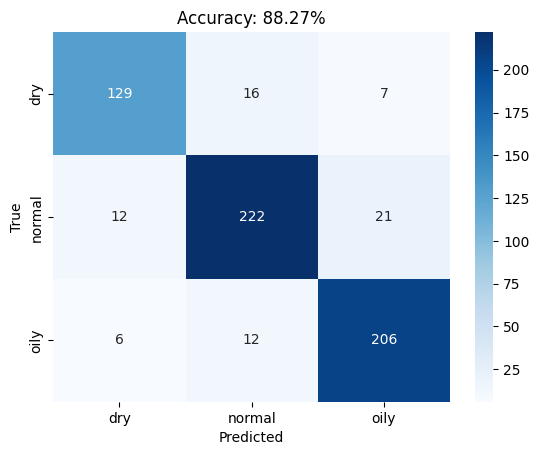

In [17]:
score = accuracy_score(y_true, y_pred)
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=index_label.values(), yticklabels=index_label.values())
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Accuracy: {}%".format(round(score*100, 2)))
plt.show()